<a href="https://colab.research.google.com/github/Anjhely1/Guia_MapReduce_Independencia_Diez/blob/main/Guia_MapReduce_Independencia_Diez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercitando con Hadoop MapReduce y Python

El objetivo de esta guía es trabajar con la resolución de ejercicios siguiendo el modelo de programación MapReduce con Python para entender los principales fundamentos de MapReduce para dar soporte a la computación paralela sobre grandes colecciones de datos en un contexto de procesamiento distribuido.
<br />

## Hadoop

El crecimiento exponencial en la disponibilidad de datos genera dos desafíos fundamentales: la necesidad de almacenamiento y su procesamiento eficiente. En pocas palabras, Hadoop afronta estos desafíos a través de las siguientes herramientas: una plataforma confiable y escalable para almacenamiento distribuido (HDFS) y análisis de estos datos (MapReduce).

A su vez, Apache Hadoop se ejecuta en hardware commodity y es de código abierto.
<br />
<br />

### Hadoop HDFS

El primer problema a resolver es la falla del hardware puesto es normal que el mismo falle cuando se lo utiliza con intensidad. Una forma común de evitar la pérdida de datos es mediante la replicación: el sistema de archivos guarda copias redundantes de los datos para que, en caso de falla, haya otra copia disponible. En el ecosistema Hadoop, el encargado de afrontar este desafío es su sistema de archivos distribuido de Hadoop (HDFS).
<br />
<br />

### MapReduce

El segundo problema es que la mayoría de las tareas de análisis deben poder combinar los datos de alguna manera, y es posible que los datos leídos de un disco deban combinarse con los datos de otros. MapReduce proporciona un modelo de programación que abstrae el problema de las lecturas y escrituras de disco, transformándolo en un cálculo sobre conjuntos de claves y valores. Para ello, MapReduce combina su operatoria en dos partes en el cálculo: el mapeo y la reducción, y es la interfaz entre las dos donde ocurre la "mezcla".

MapReduce es un procesador de consultas _batch_, con capacidad de ejecutar una consulta ad hoc en todo un conjunto de datos, del orden de los petabytes, y obtener resultados en un tiempo razonable.





## Programando en modo MapReduce

__Ejercicio: Vamos a programar un proceso MapReduce que nos permita realizar un conteo de palabras para saber, en dos datasets (`independencia.txt` y `diez.txt`), la cantidad de veces que aparece cada palabra. El mismo proceso se aplica a ambos datasets, como si fueran dos trabajos (jobs) distintos de Hadoop.__
<br /> <br />

Vamos a emular el funcionamiento de Hadoop MapReduce en función del siguiente esquema de funcionamiento [1]:

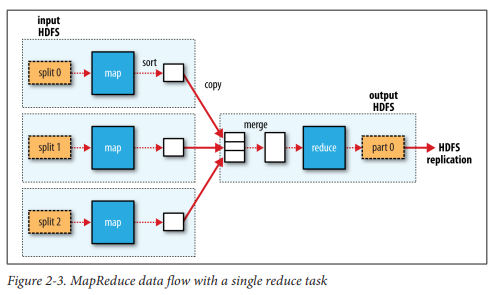

En resumen, en el siguiente ejercicio, vamos a hacer un conteo de palabras en función de la siguiente operatoria:
1. Vamos a suponer que tenemos 3 nodos que se distribuyen los datos en 3 split de datos diferentes.
1. En cada nodo se va a procesar un split diferente, transformando cada palabra a un par __<clave, valor>__ (el separador será el _tab_).
1. Luego, tendremos un sorter.py que ordenará las claves emulando la operación de Hadoop que realiza esta actividad automáticamente.
1. Luego habrá un merger que mezclará los archivos procesados en cada nodo emulando a Hadoop que realiza esta operación automáticamente.
1. En este ejercicio vamos a suponer que tenemos un único Reducer.
1. Por último, habrá un reducer.py que integrará los datos en un único archivo de salida que tendrá el procesamiento final de los datos.

En resumen, el flujo de datos puede observarse en el siguiente esquema: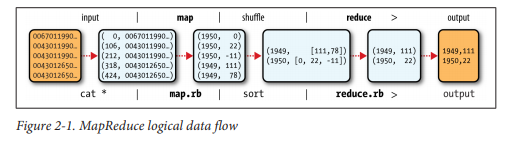

### Datasets y splits

Vamos a trabajar con dos textos en formato plano, publicados en el repositorio [bibliotxt](https://github.com/bibliotxt/bibliotxt):

| Dataset | URL |
|---|---|
| `independencia` | https://raw.githubusercontent.com/bibliotxt/bibliotxt/refs/heads/master/hacking/independencia.txt |
| `diez` | https://raw.githubusercontent.com/bibliotxt/bibliotxt/refs/heads/master/hacking/diez.txt |

En Hadoop, HDFS parte cada archivo en bloques y cada bloque lo procesa un mapper distinto. Para emularlo, cada dataset se divide en **3 splits** de líneas consecutivas (uno por nodo).

> Si subís los datasets a tu propio repositorio de GitHub (ver la sección final), alcanza con poner `USAR_REPO_PROPIO = True` y completar `BASE_URL_PROPIO`.

In [ ]:
import os
import urllib.request

# ---------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------
# Datasets originales (bibliotxt)
DATASETS = {
    "independencia": "https://raw.githubusercontent.com/bibliotxt/bibliotxt/refs/heads/master/hacking/independencia.txt",
    "diez": "https://raw.githubusercontent.com/bibliotxt/bibliotxt/refs/heads/master/hacking/diez.txt",
}

# Opcional: leer los datasets desde tu propio repositorio de GitHub
USAR_REPO_PROPIO = True
BASE_URL_PROPIO = "https://raw.githubusercontent.com/Anjhely1/Guia_MapReduce_Independencia_Diez/main/datasets"
if USAR_REPO_PROPIO:
    DATASETS = {nombre: f"{BASE_URL_PROPIO}/{nombre}.txt" for nombre in DATASETS}

N_NODOS = 3  # cantidad de nodos (mappers) = cantidad de splits


def leer_texto(path):
    """Lee un archivo de texto probando UTF-8 y, si falla, Latin-1."""
    with open(path, "rb") as f:
        datos = f.read()
    try:
        return datos.decode("utf-8")
    except UnicodeDecodeError:
        return datos.decode("latin-1")


# ---------------------------------------------------------------
# Descarga de los datasets
# ---------------------------------------------------------------
for nombre, url in DATASETS.items():
    urllib.request.urlretrieve(url, f"{nombre}.txt")

# ---------------------------------------------------------------
# Split: cada dataset se reparte en N_NODOS bloques de líneas consecutivas
# ---------------------------------------------------------------
print(f"{'dataset':<15}{'líneas':>8}  líneas por split")
for nombre in DATASETS:
    lineas = leer_texto(f"{nombre}.txt").splitlines(keepends=True)
    tam = -(-len(lineas) // N_NODOS)  # división entera hacia arriba
    cantidades = []
    for i in range(N_NODOS):
        bloque = lineas[i * tam:(i + 1) * tam]
        with open(f"{nombre}_split{i + 1}.txt", "w", encoding="utf-8") as f:
            f.writelines(bloque)
        cantidades.append(len(bloque))
    print(f"{nombre:<15}{len(lineas):>8}  {cantidades}")


dataset          líneas  líneas por split
independencia        38  [13, 13, 12]
diez                 42  [14, 14, 14]


**Mapper**###

Cada mapper leerá un split de datos y lo procesará. El objetivo de esta actividad es convertir la entrada en un par __<clave, valor>__ que permita resolver el problema. Como lo que buscamos es realizar un conteo de palabras, vamos a tomar como clave la palabra y al valor le asignaremos 1 que indicará la ocurrencia de esa palabra (el separador será el _tab_).

Para que el conteo tenga sentido, el mapper pasa el texto a minúsculas y se queda solo con las letras (así `Libertad,` y `libertad` cuentan como la misma palabra). El script lee de la entrada estándar (_stdin_) y escribe en la salida estándar (_stdout_), igual que lo haría en Hadoop Streaming.

In [ ]:
%%writefile mapper.py
#!/usr/bin/env python
"""mapper.py"""

import re
import sys

# Forzamos UTF-8 en la entrada y la salida estándar
sys.stdin.reconfigure(encoding="utf-8")
sys.stdout.reconfigure(encoding="utf-8")

# Cada mapper lee su split desde STDIN (entrada estándar)
for line in sys.stdin:
    # Minúsculas y solo letras (incluye acentos y la ñ)
    words = re.findall(r"[^\W\d_]+", line.lower())
    for word in words:
        # Se escribe <clave, valor> en STDOUT, delimitado por tabulaciones.
        # Lo que procese cada mapper será la entrada del reducer
        print(f"{word}\t1")


Writing mapper.py


In [ ]:
import subprocess

def correr(script, entrada, salida, args=()):
    """Ejecuta un script de Python leyendo `entrada` por stdin y escribiendo en `salida`."""
    with open(salida, "w", encoding="utf-8") as out:
        if entrada is None:
            subprocess.run(["python3", script, *args], stdout=out, check=True)
        else:
            with open(entrada, encoding="utf-8") as inp:
                subprocess.run(["python3", script, *args], stdin=inp, stdout=out, check=True)

# Fase MAP: cada nodo procesa su split
for nombre in DATASETS:
    for i in range(1, N_NODOS + 1):
        correr("mapper.py", f"{nombre}_split{i}.txt", f"{nombre}_map{i}.txt")

# Muestra de la salida del mapper 1 de cada dataset
for nombre in DATASETS:
    print(f"--- {nombre}_map1.txt (primeras 8 líneas) ---")
    with open(f"{nombre}_map1.txt", encoding="utf-8") as f:
        for _ in range(8):
            print(repr(f.readline().rstrip("\n")))


--- independencia_map1.txt (primeras 8 líneas) ---
'declaración\t1'
'de\t1'
'independencia\t1'
'del\t1'
'ciberespacio\t1'
'gobiernos\t1'
'del\t1'
'mundo\t1'
--- diez_map1.txt (primeras 8 líneas) ---
'los\t1'
'diez\t1'
'mandamientos\t1'
'del\t1'
'hacker\t1'
'i\t1'
'nunca\t1'
'destroces\t1'


### Mapper: Sort

Una de las operaciones que provee automáticamente Hadoop MapReduce es el sort por claves a la salida de cada nodo. Aquí lo programamos puesto que estamos emulando el funcionamiento.

In [ ]:
%%writefile sorter.py
#!/usr/bin/env python
"""sorter.py"""

import sys

sys.stdin.reconfigure(encoding="utf-8")
sys.stdout.reconfigure(encoding="utf-8")

# Una de las operaciones que provee automáticamente Hadoop es el sort por claves
# Aquí lo hacemos porque estamos emulando el funcionamiento
for line in sorted(sys.stdin, key=lambda l: l.split("\t", 1)[0]):
    sys.stdout.write(line)


Writing sorter.py


In [ ]:
# Cada nodo ordena por clave la salida de su mapper -> "part"
for nombre in DATASETS:
    for i in range(1, N_NODOS + 1):
        correr("sorter.py", f"{nombre}_map{i}.txt", f"{nombre}_part{i}.txt")

for nombre in DATASETS:
    with open(f"{nombre}_part1.txt", encoding="utf-8") as f:
        lineas = f.readlines()
    medio = len(lineas) // 2
    print(f"--- {nombre}_part1.txt (8 líneas del medio, ya ordenadas por clave) ---")
    for linea in lineas[medio:medio + 8]:
        print(repr(linea.rstrip("\n")))


--- independencia_part1.txt (8 líneas del medio, ya ordenadas por clave) ---
'mercados\t1'
'mismo\t1'
'moral\t1'
'muchos\t1'
'mundo\t1'
'mundo\t1'
'mundo\t1'
'mundo\t1'
--- diez_part1.txt (8 líneas del medio, ya ordenadas por clave) ---
'modifica\t1'
'nada\t1'
'nada\t1'
'nadie\t1'
'ningún\t1'
'no\t1'
'no\t1'
'nombre\t1'


### Reducer

En este ejercicio, como se explicó antes, vamos a suponer que tenemos un único Reducer. Este reducer hará un merge de los procesamientos (_parts_) de cada nodo emulando a Hadoop que realiza esta operación automáticamente.  
Entre sus objetivos, el __reducer__ integrará los datos en un único archivo de salida que tendrá el procesamiento final de los datos, unificando los conteos encontrados para cada clave (en este caso palabras).
<br /><br />

### Reducer: Merge

En primer lugar hacemos un merge de todas las _parts_ que son el resultado del procesamiento para cada nodo. Como cada _part_ ya está ordenada, el merge intercala las líneas manteniendo el orden por clave (un _k-way merge_), que es lo que hace Hadoop en la fase de _shuffle_.

In [ ]:
%%writefile merger.py
#!/usr/bin/env python
"""merger.py"""

import heapq
import sys

sys.stdout.reconfigure(encoding="utf-8")

# Una de las operaciones que provee automáticamente Hadoop es el merge de las
# salidas de los diferentes mappers (ya ordenadas por clave).
# Aquí lo hacemos porque estamos emulando el funcionamiento.
# Uso: python merger.py part1.txt part2.txt part3.txt
archivos = [open(path, encoding="utf-8") for path in sys.argv[1:]]

for line in heapq.merge(*archivos, key=lambda l: l.split("\t", 1)[0]):
    sys.stdout.write(line)

for f in archivos:
    f.close()


Writing merger.py


In [ ]:
# Merge de las parts de cada dataset
for nombre in DATASETS:
    parts = [f"{nombre}_part{i}.txt" for i in range(1, N_NODOS + 1)]
    correr("merger.py", None, f"{nombre}_merged.txt", args=parts)

for nombre in DATASETS:
    total = sum(1 for _ in open(f"{nombre}_merged.txt", encoding="utf-8"))
    print(f"{nombre}_merged.txt: {total} pares <palabra, 1>")


independencia_merged.txt: 875 pares <palabra, 1>
diez_merged.txt: 250 pares <palabra, 1>


### Reducer: Integración

Aquí el __reducer__ unifica los conteos encontrados para cada clave (en este caso palabras). Funciona porque el archivo llega ordenado por clave: todas las ocurrencias de una misma palabra son consecutivas, entonces alcanza con ir acumulando hasta que la palabra cambia.

In [ ]:
%%writefile reducer.py
#!/usr/bin/env python
"""reducer.py"""

import sys

sys.stdin.reconfigure(encoding="utf-8")
sys.stdout.reconfigure(encoding="utf-8")

current_word = None
current_count = 0

# Leemos cada línea proveniente de los mappers (ya ordenada y mezclada)
for line in sys.stdin:
    # Eliminamos los espacios
    line = line.strip()
    if not line:
        continue

    # Parseamos la entrada del mapper.py
    word, count = line.split("\t", 1)

    # Convertimos el contador a un entero
    try:
        count = int(count)
    except ValueError:
        # En caso que el contador no sea un entero ignoramos la línea
        continue

    # Este IF funciona porque Hadoop ordena la salida del mapper por clave
    # (aquí la clave es word) antes de que se pase al reducer.py
    if current_word == word:
        current_count += count
    else:
        if current_word is not None:
            # Escribimos el resultado a la salida estándar (STDOUT)
            print(f"{current_word}\t{current_count}")
        current_count = count
        current_word = word

# Se envía la última palabra
if current_word is not None:
    print(f"{current_word}\t{current_count}")


Writing reducer.py


In [ ]:
# Fase REDUCE: un único reducer integra el archivo mezclado de cada dataset
for nombre in DATASETS:
    correr("reducer.py", f"{nombre}_merged.txt", f"{nombre}_resultado.txt")


def leer_resultado(path):
    conteos = {}
    with open(path, encoding="utf-8") as f:
        for linea in f:
            palabra, cantidad = linea.rstrip("\n").split("\t")
            conteos[palabra] = int(cantidad)
    return conteos


resultados = {nombre: leer_resultado(f"{nombre}_resultado.txt") for nombre in DATASETS}

# Top 20 palabras más frecuentes de cada dataset
for nombre, conteos in resultados.items():
    print(f"=== {nombre}: {len(conteos)} palabras distintas, {sum(conteos.values())} palabras en total ===")
    ranking = sorted(conteos.items(), key=lambda kv: (-kv[1], kv[0]))
    for palabra, cantidad in ranking[:20]:
        print(f"{palabra:<15}{cantidad:>7}")
    print()


=== independencia: 419 palabras distintas, 875 palabras en total ===
de                  42
que                 40
no                  25
en                  24
la                  24
el                  23
a                   17
y                   14
mundo               13
las                 11
un                  11
del                 10
los                  9
por                  9
más                  8
nuestro              8
se                   7
ciberespacio         6
donde                6
nuestras             6

=== diez: 151 palabras distintas, 250 palabras en total ===
que                 13
no                  11
en                   9
a                    8
un                   6
de                   5
o                    5
tu                   5
al                   4
nunca                4
y                    4
bbs                  3
dejes                3
del                  3
el                   3
los                  3
sistema              3
te                 

### Verificación

Para comprobar que el proceso MapReduce está bien, comparamos su resultado con un conteo directo (sin dividir en nodos) sobre el texto completo de cada dataset. Ambos tienen que coincidir exactamente.

In [ ]:
import re
from collections import Counter

for nombre in DATASETS:
    texto = leer_texto(f"{nombre}.txt").lower()
    directo = Counter(re.findall(r"[^\W\d_]+", texto))
    ok = dict(directo) == resultados[nombre]
    print(f"{nombre:<15} MapReduce == conteo directo: {ok}")


independencia   MapReduce == conteo directo: True
diez            MapReduce == conteo directo: True


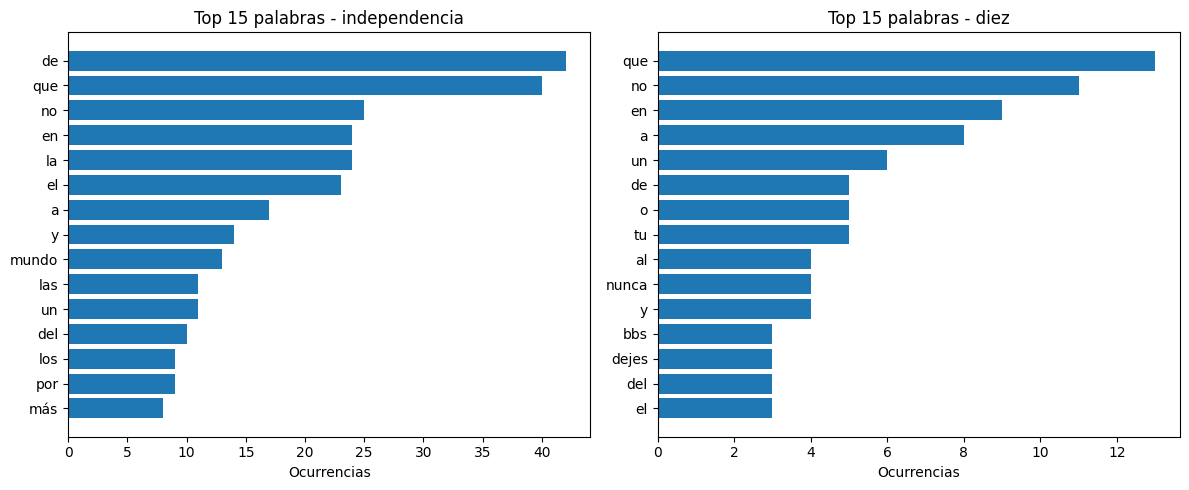

In [ ]:
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, len(resultados), figsize=(12, 5))
for eje, (nombre, conteos) in zip(ejes, resultados.items()):
    top = sorted(conteos.items(), key=lambda kv: (-kv[1], kv[0]))[:15][::-1]
    eje.barh([p for p, _ in top], [c for _, c in top])
    eje.set_title(f"Top 15 palabras - {nombre}")
    eje.set_xlabel("Ocurrencias")
plt.tight_layout()
plt.show()


> Las palabras más frecuentes suelen ser artículos y preposiciones (_de_, _la_, _que_, _el_...). Si querés ver las palabras con más contenido, podés filtrar una lista de _stopwords_ en el `mapper.py`.

## Scripts para Hadoop MapReduce

En la presente guía se emuló el funcionamiento de algunas de las características de Hadoop MapReduce mediante scripts de Python para que puedan comprenderse los conceptos fundamentales de este framework de procesamiento masivo.

Los scripts `mapper.py` y `reducer.py` que escribimos arriba leen de _stdin_ y escriben en _stdout_, así que sirven tal cual para correr el algoritmo en un entorno Hadoop con **Hadoop Streaming** (el sort y el merge los hace Hadoop solo):

```
hadoop jar $HADOOP_HOME/share/hadoop/tools/lib/hadoop-streaming-*.jar \
  -files mapper.py,reducer.py \
  -mapper "python3 mapper.py" \
  -reducer "python3 reducer.py" \
  -input /datasets/independencia.txt \
  -output /salida/independencia
```

### Subir los datasets y los scripts a GitHub

La celda siguiente arma un archivo `mapreduce_repo.zip` con esta estructura:

```
datasets/
    independencia.txt
    diez.txt
scripts/
    mapper.py
    sorter.py
    merger.py
    reducer.py
```

Para publicarlo: creá un repositorio en GitHub, descomprimí el zip y subí las carpetas (botón __Add file → Upload files__ o con `git push`). Después, en la celda de configuración, poné `USAR_REPO_PROPIO = True` y completá `BASE_URL_PROPIO` con `https://raw.githubusercontent.com/<USUARIO>/<REPOSITORIO>/master/datasets`.

In [ ]:
import zipfile

with zipfile.ZipFile("mapreduce_repo.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for nombre in DATASETS:
        z.write(f"{nombre}.txt", f"datasets/{nombre}.txt")
    for script in ["mapper.py", "sorter.py", "merger.py", "reducer.py"]:
        z.write(script, f"scripts/{script}")

print("Archivo generado: mapreduce_repo.zip")

# En Google Colab, lo descarga a tu computadora
try:
    from google.colab import files
    files.download("mapreduce_repo.zip")
except ImportError:
    pass


Archivo generado: mapreduce_repo.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Referencias

1. Hadoop: The Definitive Guide (4da edición) - Tom White. O’Reilly  Media, Inc. 2015. ISBN: 978-1-491-90163-2.
1. Hadoop: Github examples. https://github.com/tomwhite/hadoop-book
1. Writing An Hadoop MapReduce Program In Python. https://www.michael-noll.com/tutorials/writing-an-hadoop-mapreduce-program-in-python/
